# US Banking Consumer Complaints — Exploratory & Statistical Analysis

**Stage 5** of the [banking-complaints-analysis](https://github.com/sahilsharma0309/banking-complaints-analysis) project.

Source: CFPB Consumer Complaint Database, banking & lending products only,
2023-01-01 → 2026-01-01. 624,708 complaints after cleaning, enriched with FDIC
total assets.

**What this notebook answers**

1. How has complaint volume trended overall and by product?
2. Is complaint outcome (monetary relief vs none) **independent** of the product?
3. Is it independent of the **company**?
4. How do the company-level risk measures relate to each other?

**A note on statistical method.** With n = 624,708 a chi-square test will return
p ≈ 0 for essentially any association, including trivially small ones.
Significance is therefore *guaranteed* and tells us nothing. Every test below is
reported with **Cramér's V**, an effect size, and the conclusions are driven by
effect size rather than by p-values.

In [1]:
import os
import warnings
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore", category=FutureWarning)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROC = PROJECT_ROOT / "data" / "processed"
FIGS = PROJECT_ROOT / "reports" / "figures"
FIGS.mkdir(parents=True, exist_ok=True)

# Consistent, readable styling for every figure in the project.
sns.set_theme(style="whitegrid", context="notebook")
mpl.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 160,
    "savefig.bbox": "tight",
    "font.size": 10,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "figure.facecolor": "white",
    "savefig.facecolor": "white",
})
PALETTE = sns.color_palette("colorblind")
print("project root:", PROJECT_ROOT)

project root: D:\banking-complaints-project


## 1. Load

Read from PostgreSQL when `.env` is configured (the pipeline's source of truth),
otherwise fall back to the Stage 2/3 CSVs so the notebook runs for anyone who
clones the repo without a database.

In [2]:
def load_data():
    """Prefer PostgreSQL; fall back to CSV so the notebook always runs."""
    try:
        from dotenv import load_dotenv
        from sqlalchemy import create_engine
        from urllib.parse import quote_plus

        load_dotenv(PROJECT_ROOT / ".env")
        pw = os.getenv("PGPASSWORD", "")
        if not pw:
            raise RuntimeError("no PGPASSWORD configured")
        eng = create_engine(
            f"postgresql+psycopg2://{os.getenv('PGUSER','postgres')}:{quote_plus(pw)}"
            f"@{os.getenv('PGHOST','localhost')}:{os.getenv('PGPORT','5432')}"
            f"/{os.getenv('PGDATABASE','banking_complaints')}")
        with eng.connect() as c:
            df = pd.read_sql("SELECT * FROM cfpb.complaints", c)
            comp = pd.read_sql("SELECT * FROM cfpb.company_enriched", c)
        eng.dispose()
        return df, comp, "PostgreSQL (cfpb schema)"
    except Exception as exc:
        print(f"Postgres unavailable ({type(exc).__name__}) -- reading CSVs instead")
        df = pd.read_csv(PROC / "complaints_clean.csv",
                         dtype={"zip3": str, "zip_code": str},
                         parse_dates=["date_received"])
        comp = pd.read_csv(PROC / "company_enriched.csv")
        return df, comp, "CSV (data/processed)"


df, companies, source = load_data()
df["date_received"] = pd.to_datetime(df["date_received"])

print(f"source            : {source}")
print(f"complaints        : {len(df):,}")
print(f"companies         : {len(companies):,}")
print(f"date span         : {df.date_received.min():%Y-%m-%d} .. {df.date_received.max():%Y-%m-%d}")
print(f"resolved          : {df.is_resolved.sum():,}")
print(f"in trend window   : {df.in_trend_window.sum():,}")

source            : PostgreSQL (cfpb schema)
complaints        : 624,708
companies         : 3,193
date span         : 2023-01-01 .. 2026-01-01
resolved          : 624,505
in trend window   : 624,195


## 2. Complaint volume over time

Bounded to **2023-01 → 2025-12** (36 complete months). The extract window ends
2026-01-01, so 2026 contributes a single day; including it would render as a
100% collapse in the final period rather than as missing data.

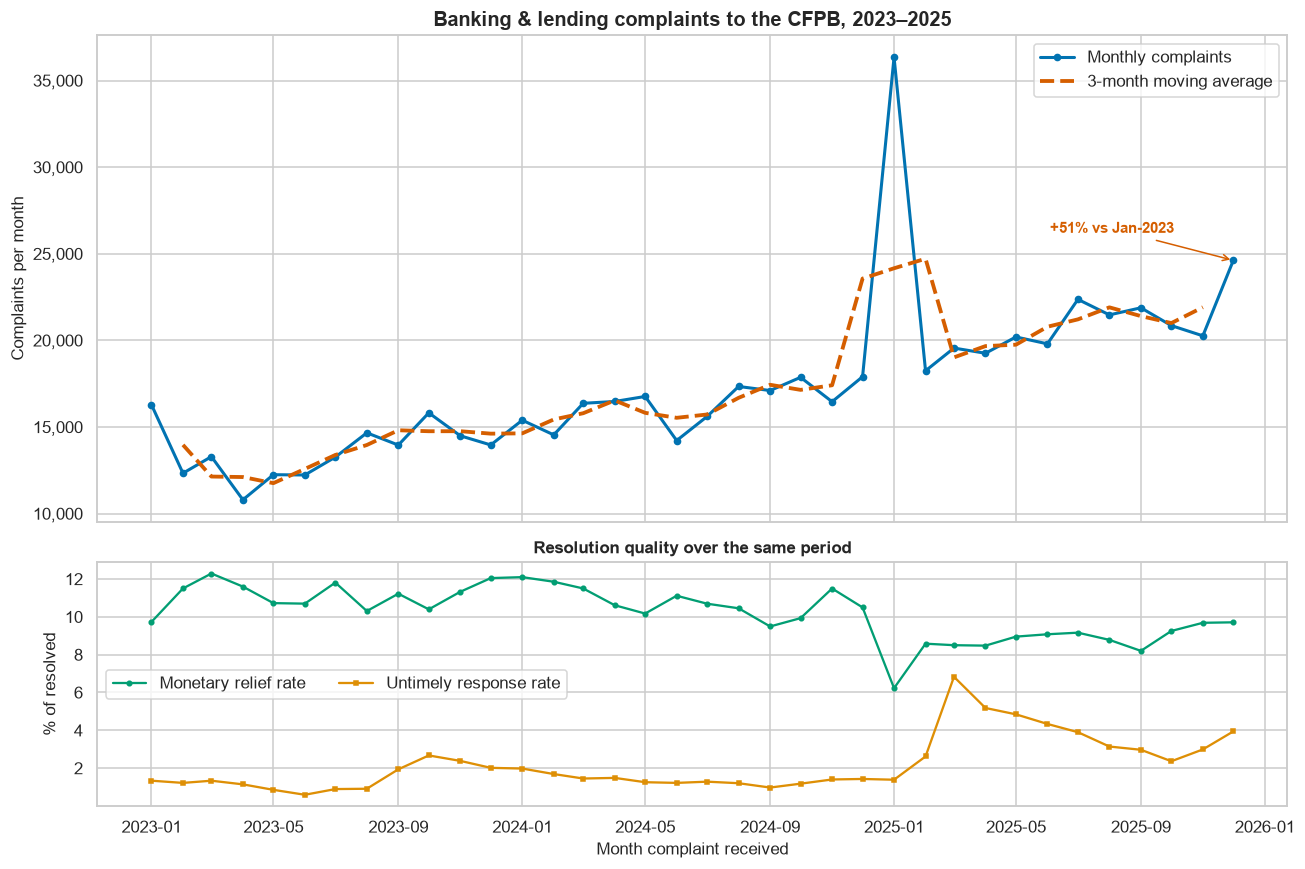

Jan-2023: 16,280   Dec-2025: 24,620   change: +51.2%
peak month: 2025-01 (36,342)


In [3]:
trend = df[df.in_trend_window].copy()
monthly = (trend.groupby("year_month")
                .agg(complaints=("complaint_id", "count"),
                     monetary_relief=("got_monetary_relief", "sum"),
                     untimely=("is_untimely", "sum"),
                     resolved=("is_resolved", "sum"))
                .reset_index())
monthly["month_dt"] = pd.to_datetime(monthly["year_month"] + "-01")
monthly["relief_rate"] = 100 * monthly.monetary_relief / monthly.resolved
monthly["untimely_rate"] = 100 * monthly.untimely / monthly.resolved

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True,
                         gridspec_kw={"height_ratios": [2, 1]})

ax = axes[0]
ax.plot(monthly.month_dt, monthly.complaints, marker="o", ms=4,
        lw=2, color=PALETTE[0], label="Monthly complaints")
ax.plot(monthly.month_dt, monthly.complaints.rolling(3, center=True).mean(),
        lw=2.5, ls="--", color=PALETTE[3], label="3-month moving average")
ax.set_title("Banking & lending complaints to the CFPB, 2023–2025")
ax.set_ylabel("Complaints per month")
ax.legend(frameon=True)
ax.yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter("{x:,.0f}"))

first, last = monthly.complaints.iloc[0], monthly.complaints.iloc[-1]
ax.annotate(f"{(last/first - 1)*100:+.0f}% vs Jan-2023",
            xy=(monthly.month_dt.iloc[-1], last),
            xytext=(-120, 18), textcoords="offset points",
            fontsize=10, fontweight="bold", color=PALETTE[3],
            arrowprops=dict(arrowstyle="->", color=PALETTE[3]))

ax = axes[1]
ax.plot(monthly.month_dt, monthly.relief_rate, marker="o", ms=3,
        color=PALETTE[2], label="Monetary relief rate")
ax.plot(monthly.month_dt, monthly.untimely_rate, marker="s", ms=3,
        color=PALETTE[1], label="Untimely response rate")
ax.set_title("Resolution quality over the same period", fontsize=11)
ax.set_ylabel("% of resolved")
ax.set_xlabel("Month complaint received")
ax.legend(frameon=True, ncol=2)

plt.tight_layout()
plt.savefig(FIGS / "fig_01_monthly_trend_overall.png")
plt.show()

print(f"Jan-2023: {first:,}   Dec-2025: {last:,}   change: {(last/first-1)*100:+.1f}%")
print(f"peak month: {monthly.loc[monthly.complaints.idxmax(),'year_month']} "
      f"({monthly.complaints.max():,})")

### 2.1 By product

Uses the **cleaned** `product` column. On the raw labels this chart shows `Credit card` appearing out of nothing in Aug-2023 — an artefact of a CFPB taxonomy rename, not a real surge. See `reports/cleaning_log.md`.

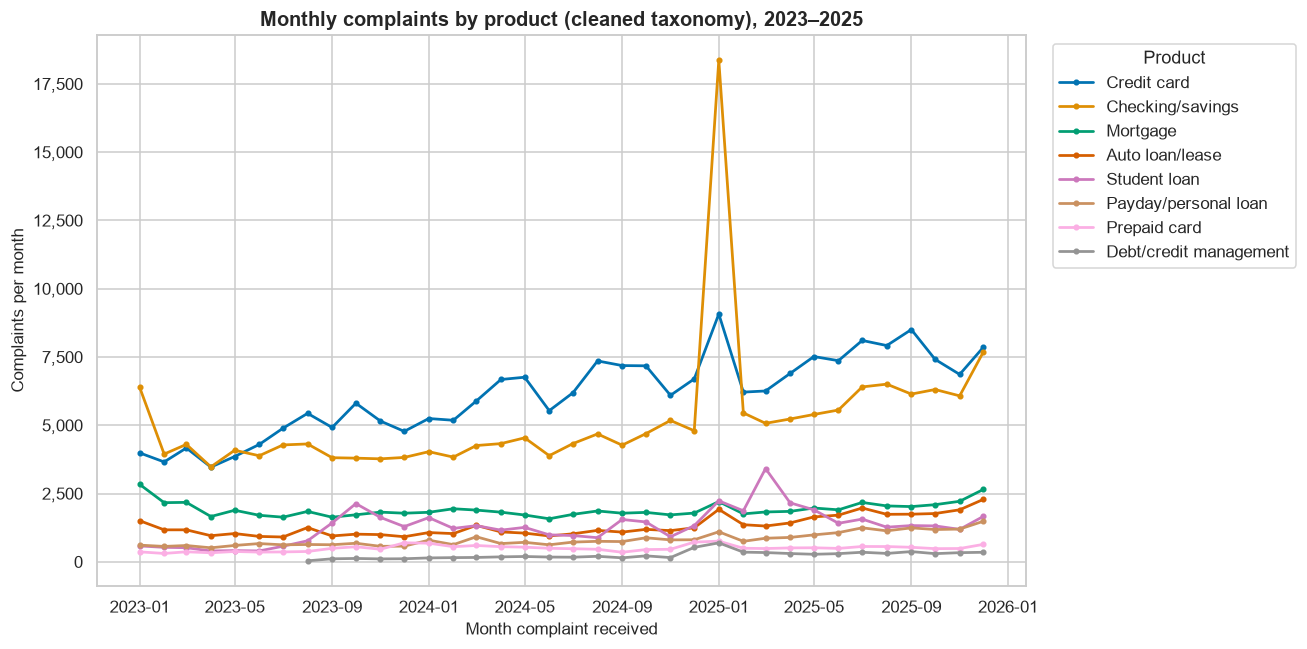

Growth, first 3 months vs last 3 months of the window:
  Debt/credit management     +267.0%
  Student loan               +156.7%
  Payday/personal loan       +118.4%
  Credit card                 +87.4%
  Prepaid card                +55.1%
  Auto loan/lease             +54.9%
  Checking/savings            +37.1%
  Mortgage                     -3.1%


In [4]:
by_prod = (trend.groupby(["year_month", "product_short"])
                .size().reset_index(name="complaints"))
by_prod["month_dt"] = pd.to_datetime(by_prod["year_month"] + "-01")
order = (trend.product_short.value_counts().index.tolist())

fig, ax = plt.subplots(figsize=(12, 6))
for i, prod in enumerate(order):
    s = by_prod[by_prod.product_short == prod]
    ax.plot(s.month_dt, s.complaints, marker="o", ms=3, lw=1.8,
            label=prod, color=PALETTE[i % len(PALETTE)])

ax.set_title("Monthly complaints by product (cleaned taxonomy), 2023–2025")
ax.set_ylabel("Complaints per month")
ax.set_xlabel("Month complaint received")
ax.legend(title="Product", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True)
ax.yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter("{x:,.0f}"))
plt.tight_layout()
plt.savefig(FIGS / "fig_02_monthly_trend_by_product.png")
plt.show()

growth = (by_prod.groupby("product_short")
          .apply(lambda g: 100*(g.sort_values("year_month").complaints.iloc[-3:].mean()
                 / g.sort_values("year_month").complaints.iloc[:3].mean() - 1))
          .sort_values(ascending=False))
print("Growth, first 3 months vs last 3 months of the window:")
for p, v in growth.items():
    print(f"  {p:<24} {v:+8.1f}%")

## 3. Chi-square test — is outcome independent of product?

**H₀:** whether a complaint ends in monetary relief is independent of the product.
**H₁:** relief depends on the product.

Reported with **Cramér's V**, because at n ≈ 600k the p-value is a foregone
conclusion.

In [5]:
def chi_square_report(ct: pd.DataFrame, label: str):
    chi2, p, dof, expected = stats.chi2_contingency(ct)
    n = ct.values.sum()
    k = min(ct.shape) - 1
    v = np.sqrt(chi2 / (n * k))
    if v < 0.10:   strength = "negligible"
    elif v < 0.20: strength = "weak"
    elif v < 0.30: strength = "moderate"
    else:          strength = "strong"

    print(f"=== {label} ===")
    print(f"  chi-square statistic : {chi2:,.1f}")
    print(f"  degrees of freedom   : {dof}")
    print(f"  p-value              : {'< 1e-300' if p < 1e-300 else f'{p:.3e}'}")
    print(f"  n                    : {n:,}")
    print(f"  Cramer's V           : {v:.4f}  ({strength} association)")
    resid = (ct.values - expected) / np.sqrt(expected)
    return chi2, p, v, pd.DataFrame(resid, index=ct.index, columns=ct.columns)


res = df[df.is_resolved].copy()
res["outcome"] = np.where(res.got_monetary_relief, "Monetary relief", "No monetary relief")

ct_product = pd.crosstab(res.product_short, res.outcome)
chi2_p, p_p, v_p, resid_p = chi_square_report(ct_product, "Outcome x Product")

rates = (100 * ct_product["Monetary relief"] / ct_product.sum(axis=1)).sort_values()
print("\nMonetary relief rate by product:")
for prod, r in rates.items():
    print(f"  {prod:<24} {r:5.2f}%   (n={ct_product.loc[prod].sum():,})")

=== Outcome x Product ===
  chi-square statistic : 21,575.1
  degrees of freedom   : 7
  p-value              : < 1e-300
  n                    : 624,505
  Cramer's V           : 0.1859  (weak association)

Monetary relief rate by product:
  Student loan              0.80%   (n=46,437)
  Mortgage                  2.00%   (n=69,026)
  Auto loan/lease           2.42%   (n=46,977)
  Debt/credit management    3.54%   (n=7,170)
  Payday/personal loan      3.73%   (n=29,445)
  Checking/savings         12.84%   (n=187,037)
  Credit card              13.54%   (n=220,544)
  Prepaid card             21.88%   (n=17,869)


### 3.1 Which products drive the result?

The chi-square statistic is a single number for the whole table. **Standardised
residuals** show which cells actually deviate from independence: values beyond
±2 are the ones doing the work.

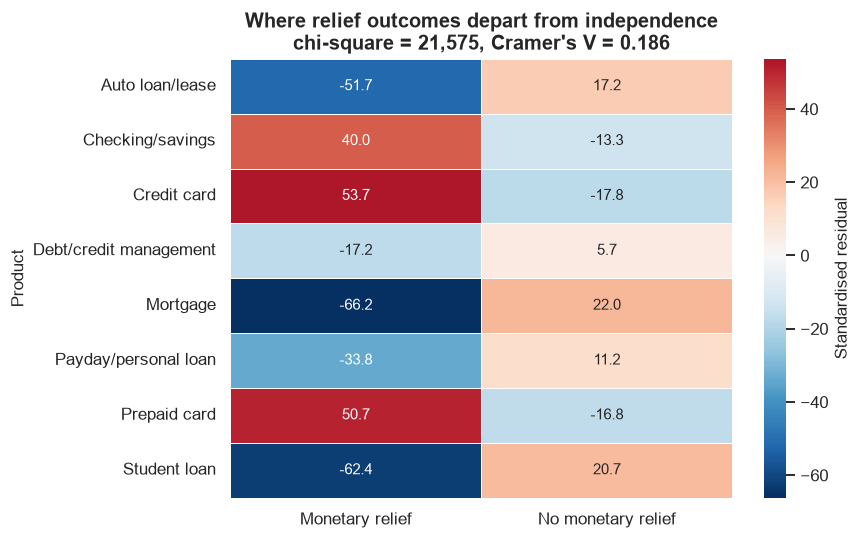

Cells beyond +/-2 (the ones driving the association):
  Mortgage                 Monetary relief       -66.2  FEWER than expected
  Student loan             Monetary relief       -62.4  FEWER than expected
  Auto loan/lease          Monetary relief       -51.7  FEWER than expected
  Payday/personal loan     Monetary relief       -33.8  FEWER than expected
  Mortgage                 No monetary relief    +22.0  MORE than expected
  Checking/savings         Monetary relief       +40.0  MORE than expected
  Prepaid card             Monetary relief       +50.7  MORE than expected
  Credit card              Monetary relief       +53.7  MORE than expected


In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(resid_p, annot=True, fmt=".1f", center=0, cmap="RdBu_r",
            cbar_kws={"label": "Standardised residual"}, ax=ax,
            linewidths=.5, linecolor="white")
ax.set_title(f"Where relief outcomes depart from independence\n"
             f"chi-square = {chi2_p:,.0f}, Cramer's V = {v_p:.3f}")
ax.set_xlabel("")
ax.set_ylabel("Product")
plt.tight_layout()
plt.savefig(FIGS / "fig_03_chisquare_residuals_product.png")
plt.show()

print("Cells beyond +/-2 (the ones driving the association):")
flat = resid_p.stack().sort_values()
for (prod, out), v in pd.concat([flat.head(4), flat.tail(4)]).items():
    direction = "MORE than expected" if v > 0 else "FEWER than expected"
    print(f"  {prod:<24} {out:<20} {v:+6.1f}  {direction}")

## 4. Chi-square test — is outcome independent of company?

Restricted to companies with **≥ 500 resolved complaints**, so the test measures
real differences rather than small-sample noise.

In [7]:
big = res.groupby("company").size()
big = big[big >= 500].index
res_big = res[res.company.isin(big)]

ct_company = pd.crosstab(res_big.company, res_big.outcome)
chi2_c, p_c, v_c, resid_c = chi_square_report(
    ct_company, f"Outcome x Company ({len(big)} companies, >=500 resolved)")

comp_rates = (100 * ct_company["Monetary relief"] / ct_company.sum(axis=1))
print(f"\nrelief rate spread across these {len(big)} companies:")
print(f"  min    {comp_rates.min():6.2f}%   ({comp_rates.idxmin()})")
print(f"  median {comp_rates.median():6.2f}%")
print(f"  max    {comp_rates.max():6.2f}%   ({comp_rates.idxmax()})")
print(f"  ratio max/median: {comp_rates.max()/max(comp_rates.median(),0.01):.1f}x")

=== Outcome x Company (112 companies, >=500 resolved) ===
  chi-square statistic : 65,030.7
  degrees of freedom   : 111
  p-value              : < 1e-300
  n                    : 560,716
  Cramer's V           : 0.3406  (strong association)

relief rate spread across these 112 companies:
  min      0.00%   (Affirm Holdings, Inc)
  median   1.25%
  max     38.53%   (Bread Financial Holdings, Inc.)
  ratio max/median: 30.8x


## 5. How the company-level risk measures relate

The macro correlation (unemployment / CPI vs volume) planned for this stage was
**deliberately dropped**: no FRED key is configured, and 36 monthly observations
cannot support a credible macro claim — see `reports/enrichment_log.md`. A
correlation matrix of the company-level risk measures is substituted, which
speaks directly to the business question instead.

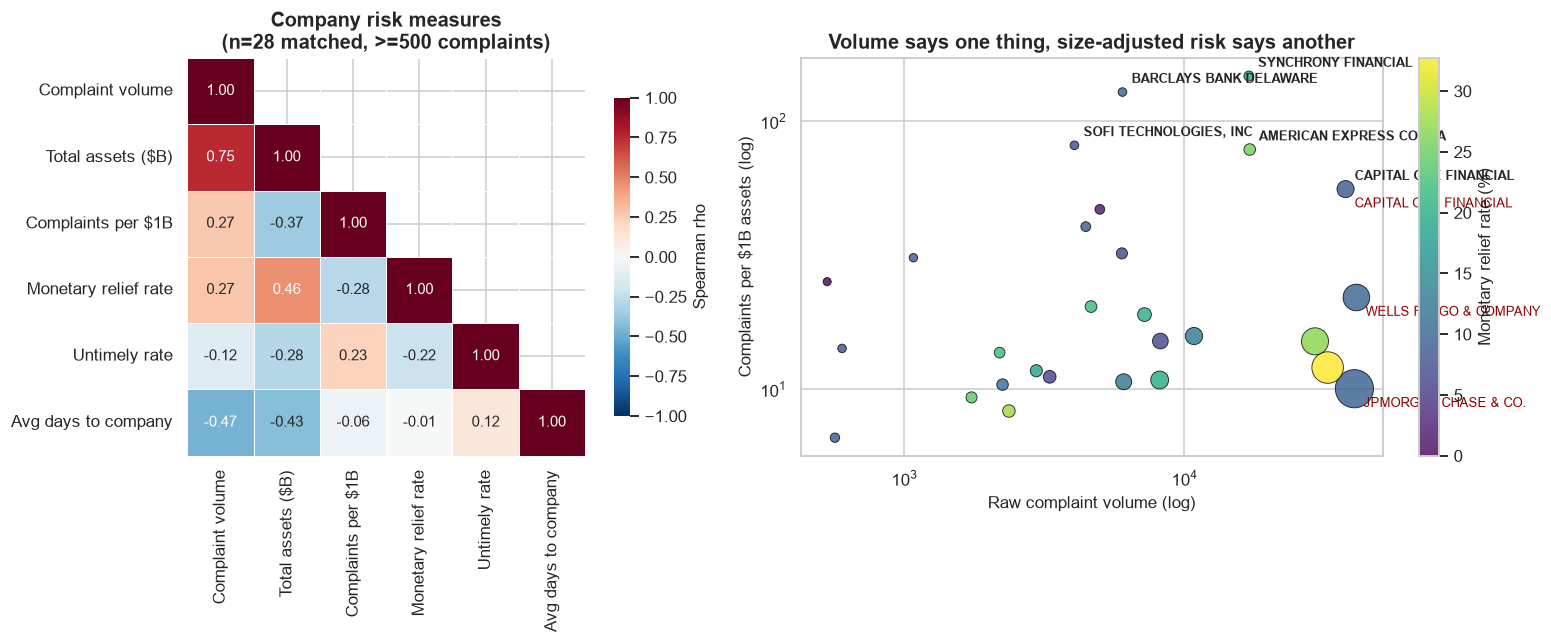

Spearman correlation with complaints per $1B:
  Total assets ($B)        -0.366
  Monetary relief rate     -0.278
  Avg days to company      -0.059
  Untimely rate            +0.228
  Complaint volume         +0.268


In [8]:
m = companies[companies.matched & (companies.total_complaints >= 500)].copy()
cols = {
    "total_complaints": "Complaint volume",
    "total_assets_b": "Total assets ($B)",
    "complaints_per_1b_assets": "Complaints per $1B",
    "monetary_relief_rate": "Monetary relief rate",
    "untimely_rate": "Untimely rate",
    "avg_days_to_company": "Avg days to company",
}
corr_df = m[list(cols)].rename(columns=cols)
corr = corr_df.corr(method="spearman")   # Spearman: these are skewed, not normal

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5),
                         gridspec_kw={"width_ratios": [1, 1.25]})

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", center=0, cmap="RdBu_r",
            vmin=-1, vmax=1, square=True, linewidths=.5, ax=axes[0],
            cbar_kws={"label": "Spearman rho", "shrink": .8})
axes[0].set_title(f"Company risk measures\n(n={len(m)} matched, >=500 complaints)")

ax = axes[1]
sizes = (m.total_assets_b / m.total_assets_b.max() * 600 + 25)
sc = ax.scatter(m.total_complaints, m.complaints_per_1b_assets, s=sizes,
                c=m.monetary_relief_rate, cmap="viridis",
                alpha=.8, edgecolor="black", linewidth=.6)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("Raw complaint volume (log)")
ax.set_ylabel("Complaints per $1B assets (log)")
ax.set_title("Volume says one thing, size-adjusted risk says another")
plt.colorbar(sc, ax=ax, label="Monetary relief rate (%)")

for _, r in m.nlargest(5, "complaints_per_1b_assets").iterrows():
    ax.annotate(r.company[:22], (r.total_complaints, r.complaints_per_1b_assets),
                xytext=(6, 6), textcoords="offset points", fontsize=8.5,
                fontweight="bold")
for _, r in m.nlargest(3, "total_complaints").iterrows():
    ax.annotate(r.company[:22], (r.total_complaints, r.complaints_per_1b_assets),
                xytext=(6, -12), textcoords="offset points", fontsize=8.5,
                color="darkred")

plt.tight_layout()
plt.savefig(FIGS / "fig_04_risk_correlation_and_scatter.png")
plt.show()

print("Spearman correlation with complaints per $1B:")
for k, v in corr["Complaints per $1B"].drop("Complaints per $1B").sort_values().items():
    print(f"  {k:<24} {v:+.3f}")

## 6. The contrast that matters

Companies ranked by raw volume against the same companies ranked per $1B of
assets. The gap between the two ranks is the finding.

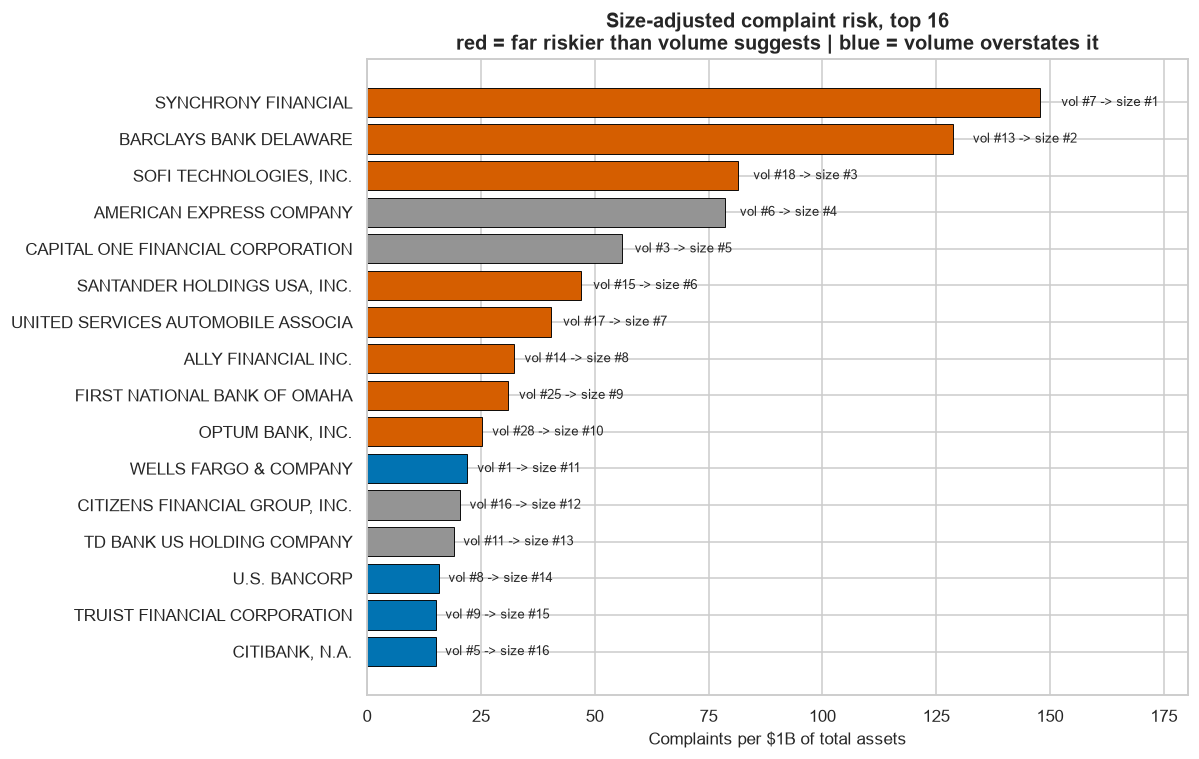

Biggest 'looks fine on volume, isn't' gaps:
  OPTUM BANK, INC.                       vol #28  -> size #10  (+18)  25.2/$1B
  FIRST NATIONAL BANK OF OMAHA           vol #25  -> size #9   (+16)  31.0/$1B
  SOFI TECHNOLOGIES, INC.                vol #18  -> size #3   (+15)  81.5/$1B
  BARCLAYS BANK DELAWARE                 vol #13  -> size #2   (+11)  128.8/$1B
  UNITED SERVICES AUTOMOBILE ASSOCIATION vol #17  -> size #7   (+10)  40.5/$1B
  SANTANDER HOLDINGS USA, INC.           vol #15  -> size #6   (+9)  47.0/$1B


In [9]:
m2 = m.copy()
m2["volume_rank"] = m2.total_complaints.rank(ascending=False).astype(int)
m2["size_rank"] = m2.complaints_per_1b_assets.rank(ascending=False).astype(int)
m2["gap"] = m2.volume_rank - m2.size_rank
top = m2.nsmallest(16, "size_rank").sort_values("complaints_per_1b_assets")

fig, ax = plt.subplots(figsize=(11, 7))
colors = [PALETTE[3] if g >= 5 else (PALETTE[0] if g <= -5 else PALETTE[7])
          for g in top.gap]
bars = ax.barh(top.company.str[:34], top.complaints_per_1b_assets, color=colors,
               edgecolor="black", linewidth=.6)
for bar, (_, r) in zip(bars, top.iterrows()):
    ax.text(bar.get_width() * 1.02, bar.get_y() + bar.get_height()/2,
            f"  vol #{r.volume_rank} -> size #{r.size_rank}",
            va="center", fontsize=8.5)
ax.set_xlabel("Complaints per $1B of total assets")
ax.set_title("Size-adjusted complaint risk, top 16\n"
             "red = far riskier than volume suggests | blue = volume overstates it")
ax.margins(x=.22)
plt.tight_layout()
plt.savefig(FIGS / "fig_05_size_adjusted_ranking.png")
plt.show()

print("Biggest 'looks fine on volume, isn't' gaps:")
for _, r in m2.nlargest(6, "gap")[["company", "volume_rank", "size_rank", "gap",
                                   "complaints_per_1b_assets"]].iterrows():
    print(f"  {r.company[:38]:<38} vol #{r.volume_rank:<3} -> size #{r.size_rank:<3} "
          f"(+{r.gap})  {r.complaints_per_1b_assets:,.1f}/$1B")

## 7. Anomaly: the January 2025 mass-filing event

The overall trend chart has an obvious spike — **36,342 complaints in Jan-2025
against a ~18,000 baseline**, which then reverts immediately. A spike that
reverts is rarely organic demand, so it is worth identifying before any
conclusion is drawn from company rankings.

In [10]:
jan = trend[trend.year_month == "2025-01"]
dec = trend[trend.year_month == "2024-12"]
jc, dc = jan.company.value_counts(), dec.company.value_counts()

delta = (pd.DataFrame({"jan_2025": jc, "dec_2024": dc}).fillna(0).astype(int)
           .assign(increase=lambda d: d.jan_2025 - d.dec_2024)
           .nlargest(6, "increase"))
print("Biggest increases, Dec-2024 -> Jan-2025:")
print(delta.to_string())

spike_size = len(jan) - len(dec)
top2 = delta.increase.head(2).sum()
print(f"\nspike size            : {spike_size:,} extra complaints")
print(f"top 2 companies       : {top2:,}  ({100*top2/spike_size:.0f}% of the spike)")

daily = jan.groupby(jan.date_received.dt.day).size()
print(f"peak day              : Jan {daily.idxmax()} with {daily.max():,} "
      f"(median day {daily.median():,.0f})")
print("\ndominant issues in the spike month:")
for (p, i), n in jan.groupby(["product_short", "issue"]).size().nlargest(4).items():
    print(f"  {n:>6,}  {p} / {i}")

Biggest increases, Dec-2024 -> Jan-2025:
                                        jan_2025  dec_2024  increase
company                                                             
NAVY FEDERAL CREDIT UNION                   7725       484      7241
CAPITAL ONE FINANCIAL CORPORATION           5876       840      5036
Block, Inc.                                  794       177       617
JPMORGAN CHASE & CO.                        1517      1140       377
TRANSUNION INTERMEDIATE HOLDINGS, INC.      1044       692       352
EQUIFAX, INC.                                976       662       314

spike size            : 18,441 extra complaints
top 2 companies       : 12,277  (67% of the spike)
peak day              : Jan 17 with 4,978 (median day 933)

dominant issues in the spike month:
   8,232  Checking/savings / Managing an account
   7,570  Checking/savings / Problem caused by your funds being low
   1,588  Credit card / Problem with a company's investigation into an existing problem
   1,4

### 7.1 Why this matters, and a sensitivity check

Two companies account for roughly two-thirds of the spike, it is concentrated in
a few mid-January days, and it is dominated by overdraft/NSF-flavoured issues
(*'Problem caused by your funds being low'*). That is the signature of a
**coordinated filing campaign** — typically following an enforcement action or
litigation — not a change in underlying service quality.

This is not a data error and the complaints are real, so they are **not
removed**. But a ranking that treats them as ordinary demand will misstate the
affected companies, so the table below re-computes the headline metric with the
month excluded to show how much of each company's position depends on it.

In [11]:
affected = delta.index[:2].tolist()
excl = trend[trend.year_month != "2025-01"]

def per_company(frame, label):
    g = frame.groupby("company").size().rename(label)
    return g

cmp_df = (pd.concat([per_company(trend, "with_jan25"),
                     per_company(excl, "without_jan25")], axis=1)
            .fillna(0).astype(int))
cmp_df = cmp_df.join(companies.set_index("company")[["total_assets_b", "matched"]])
cmp_df = cmp_df[cmp_df.matched.fillna(False) & (cmp_df.with_jan25 >= 500)]
cmp_df["rate_with"] = (cmp_df.with_jan25 / cmp_df.total_assets_b).round(2)
cmp_df["rate_without"] = (cmp_df.without_jan25 / cmp_df.total_assets_b).round(2)
cmp_df["rank_with"] = cmp_df.rate_with.rank(ascending=False).astype(int)
cmp_df["rank_without"] = cmp_df.rate_without.rank(ascending=False).astype(int)
cmp_df["pct_from_jan25"] = (100 * (cmp_df.with_jan25 - cmp_df.without_jan25)
                            / cmp_df.with_jan25).round(1)

shifted = cmp_df[cmp_df.pct_from_jan25 > 5].sort_values("pct_from_jan25",
                                                        ascending=False)
print("Companies whose totals depend materially on the Jan-2025 event:")
print(shifted[["with_jan25", "without_jan25", "pct_from_jan25",
               "rate_with", "rate_without", "rank_with", "rank_without"]]
      .to_string())

print("\nHeadline ranking is otherwise stable: "
      f"{(cmp_df.rank_with == cmp_df.rank_without).sum()} of {len(cmp_df)} "
      "companies keep the same size-adjusted rank when the month is excluded.")

Companies whose totals depend materially on the Jan-2025 event:
                                   with_jan25  without_jan25  pct_from_jan25  rate_with  rate_without  rank_with  rank_without
company                                                                                                                       
CAPITAL ONE FINANCIAL CORPORATION       37530          31654            15.7      55.85         47.10          5             5
SOFI TECHNOLOGIES, INC.                  4039           3796             6.0      81.32         76.43          3             3
OPTUM BANK, INC.                          530            502             5.3      25.24         23.91         10            10

Headline ranking is otherwise stable: 28 of 28 companies keep the same size-adjusted rank when the month is excluded.


## 8. Summary

Populated from the computed values above — see `reports/insights.md` for the
business write-up with recommendations.

In [12]:
print("=" * 74)
print("STAGE 5 FINDINGS")
print("=" * 74)
print(f"1. Volume trend: {(last/first-1)*100:+.0f}% from Jan-2023 to Dec-2025 "
      f"({first:,} -> {last:,} complaints/month).")
print(f"2. Outcome vs PRODUCT : chi-square={chi2_p:,.0f}, Cramer's V={v_p:.3f} "
      f"-- statistically certain, practically {'weak' if v_p < .2 else 'moderate'}.")
print(f"3. Outcome vs COMPANY : chi-square={chi2_c:,.0f}, Cramer's V={v_c:.3f} "
      f"-- {'stronger' if v_c > v_p else 'weaker'} than product "
      f"({v_c/v_p:.1f}x).")
print(f"   -> WHO you complain to matters "
      f"{'more' if v_c > v_p else 'less'} than WHAT you complain about.")
print(f"4. Relief rate spread across companies: {comp_rates.min():.1f}% to "
      f"{comp_rates.max():.1f}% (median {comp_rates.median():.1f}%).")
print(f"5. Spearman(volume, complaints per $1B) = "
      f"{corr.loc['Complaint volume','Complaints per $1B']:+.3f} "
      f"-- raw volume is a poor proxy for size-adjusted risk.")
print(f"6. Jan-2025 is a mass-filing event, not organic demand: {spike_size:,} "
      f"extra complaints, {100*top2/spike_size:.0f}% from 2 companies. "
      f"Flagged, not removed; ranking verified stable without it.")
print("=" * 74)
print(f"\nfigures written to {FIGS.relative_to(PROJECT_ROOT)}:")
for f in sorted(FIGS.glob('*.png')):
    print(f"  {f.name}  ({f.stat().st_size/1024:.0f} KB)")

STAGE 5 FINDINGS
1. Volume trend: +51% from Jan-2023 to Dec-2025 (16,280 -> 24,620 complaints/month).
2. Outcome vs PRODUCT : chi-square=21,575, Cramer's V=0.186 -- statistically certain, practically weak.
3. Outcome vs COMPANY : chi-square=65,031, Cramer's V=0.341 -- stronger than product (1.8x).
   -> WHO you complain to matters more than WHAT you complain about.
4. Relief rate spread across companies: 0.0% to 38.5% (median 1.3%).
5. Spearman(volume, complaints per $1B) = +0.268 -- raw volume is a poor proxy for size-adjusted risk.
6. Jan-2025 is a mass-filing event, not organic demand: 18,441 extra complaints, 67% from 2 companies. Flagged, not removed; ranking verified stable without it.

figures written to reports\figures:
  fig_01_monthly_trend_overall.png  (183 KB)
  fig_02_monthly_trend_by_product.png  (174 KB)
  fig_03_chisquare_residuals_product.png  (78 KB)
  fig_04_risk_correlation_and_scatter.png  (195 KB)
  fig_05_size_adjusted_ranking.png  (149 KB)
